In [1]:
import os
os.getcwd()

'd:\\Dscribe\\discharge-agent\\agent'

In [1]:
import sys
import os

# Navigate to the Dscribe directory and add discharge-agent to path
os.chdir(r'd:\Dscribe')
sys.path.insert(0, os.path.join(os.getcwd(), 'discharge-agent'))

In [2]:
from agent.graph import build_graph

d:\Dscribe\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


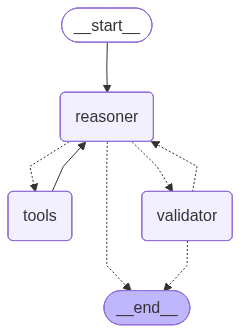

In [3]:
build_graph()

In [7]:
from ingestion.document_processor import DocumentProcessor

from pypdf import PdfReader, PdfWriter

doc_processor = DocumentProcessor()
def read_document_pages(file_path: str, start_page: int, end_page: int) -> str:
    """
    CRITICAL: Use this tool to read a medical PDF safely.
    Because medical files are massive, you must read them in chunks (e.g., 1-5, then 6-10).
    Provide the file_path, the start_page, and the end_page.
    """
    print(f"SYSTEM LOG: Agent requested pages {start_page} to {end_page}...")

    try:
        reader = PdfReader(file_path)
        total_pages = len(reader.pages)

        # Guardrails for page limits
        start_idx = max(0, start_page - 1)
        end_idx = min(total_pages, end_page)

        # 1. Slice out the specific pages
        writer = PdfWriter()
        for i in range(start_idx, end_idx):
            writer.add_page(reader.pages[i])

        # 2. Save the tiny chunk to a temp file
        temp_chunk_path = "temp_agent_chunk.pdf"
        with open(temp_chunk_path, "wb") as f:
            writer.write(f)

        markdown_text = doc_processor.process_pdf_to_markdown(temp_chunk_path)

        # Cleanup
        if os.path.exists(temp_chunk_path):
            os.remove(temp_chunk_path)

        return (
            f"--- CONTENT FOR PAGES {start_page} TO {end_page} ---\n\n{markdown_text}"
        )

    except Exception as e:
        return f"ERROR Reading Document: {str(e)}"

In [14]:
read_document_pages("discharge-agent/agent/patient2.pdf", 1, 5)

SYSTEM LOG: Agent requested pages 1 to 5...


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-06-03 09:32:49,723 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-06-03 09:32:49,736 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-06-03 09:32:49,768 [RapidOCR] download_file.py:60: File exists and is valid: D:\Dscribe\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-06-03 09:32:49,769 [RapidOCR] main.py:50: Using D:\Dscribe\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-06-03 09:32:50,165 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-06-03 09:32:50,167 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-06-03 09:32:50,170 [RapidOCR] download_file.py:60: File exists and is valid: D:\Dscribe\.venv\Lib\site-packag

"--- CONTENT FOR PAGES 1 TO 5 ---\n\n## DIAGNOSIS:\n\n## 1)ACUTE GASTROENTERITISWITHDEHYDRATION 2)URINARYTRACTINFECTION\n\nHISTORY: C/O Multiple episodesofloose stools,2-3 episodes ofvomiting fatigue since 3 days and fever since yesterday. Initially she was treated at local clinic.\n\nPAST HISTORY:K/C/O Thyroid disorder on treatment.\n\n## PHYSICALEXAMINATION:\n\nPR-89/min,BP-130/80 mmHg.RR-20/min, SPO2-98% at room air. CNS-Conscious Oriented CVS-SIS2(+) RS-B/LNVBS(+) PA-Soft,non tender\n\n## INVESTIGATIONS:\n\nReports Enclosed\n\n## COURSEINTHEHOSPITAL:\n\nPatient presented to us with above mentioned complaints. After evaluation, she was admitted to ward. Initial investigations showed normal CBC.Serum creatinine (l.65mg/dl) done was elevated. Serum electrolytes done showed low serum sodium(128.00mnol/L). Urine routine done showed ketone bodies(+), 1012/hpf of pus cells,15-20/hpf of epithelial cells with presence of bactreia hence urine culture and sensitivity sent- report awaited. She